In [1]:
import utils
import numpy as np
import pandas as pd
import os
import importlib
import re
from scipy.stats import gaussian_kde

importlib.reload(utils)

import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

pd.set_option('future.no_silent_downcasting', True)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', 20)
#pd.set_option('display.width', 1000)

In [2]:
# Preparation
dataset = 'TUS' # TUS, joystick, speakup, africa

# Loads the datapath, subject_id's and session numbers based on whether we're analysing the study or pilot data
if dataset == 'TUS' or dataset == 'joystick':
    raw_output_path = '/Volumes/project/3025011.02/raw'
    unique_subject_ids = [52, 53] #[52, 53, 54, 55, 57]
    unique_sessions = [2, 3, 4]
elif dataset == 'pilot':
    raw_output_path = '/Volumes/project/3025011.02/long_experiment_data/phd_1_task/experiment_output'
    unique_subject_ids = [5]#[5, 10, 14, 15, 16, 20, 22, 23, 25, 28, 29, 37, 38]
    unique_sessions = [2, 3, 4]
elif dataset=='speakup':
    raw_output_path = '/Volumes/project/3025011.01/4kenneth/SpeakUp!2.0/experiment_output'
    unique_subject_ids = [2]#[2, 3, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25]
    unique_sessions = [3]
elif dataset=='africa':
    raw_output_path = '/Volumes/project/3025011.01/4kenneth/RL_task-speakup_version_martin_southafrica/experiment_output'
    unique_subject_ids = [2]#[2, 3, 4, 5, 6, 8, 9, 10, 12, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
    unique_sessions = [1]

# Make output folder
output_dir = os.path.join('..','plots',dataset,'behavioural','speed-accuracy_trade-off')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Load and combine the datasets
combined_results_dataframe_all_sessions = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions, dataset)

# Invert objectively_correct score
combined_results_dataframe_all_sessions['objectively_incorrect_boolean'] = 1 - combined_results_dataframe_all_sessions['objectively_correct_boolean']

# RT in milliseconds
combined_results_dataframe_all_sessions['RT_ms'] = combined_results_dataframe_all_sessions['RT_s'] * 1000

These participants will be excluded: {'sub-011_session-02', 'sub-011_session-04', 'sub-011_session-01', 'sub-016_session-04', 'sub-011_session-03'}



# Inverse efficiency score
IES = subject's average RT on correct trials (ms) / 1 - proportion of errors (0.10 for example).\
The higher the score, the less efficient their behaviour.\
Scores can increase with an increase in error rate and/or an increase in RT.

In [3]:
IES_dataframe_sessions = utils.analysis_functions.calculate_IES(combined_results_dataframe)
IES_dataframe_congruency = utils.analysis_functions.calculate_IES(combined_results_dataframe, ['congruency'])
IES_dataframe_volatility = utils.analysis_functions.calculate_IES(combined_results_dataframe, ['volatility'])
IES_dataframe_congruency_volatility = utils.analysis_functions.calculate_IES(combined_results_dataframe, ['congruency', 'volatility'])

NameError: name 'combined_results_dataframe' is not defined

## Plot the Inverse Efficiency Score

In [5]:
all_session_labels = [1, 2, 3, 4]
if all(s in unique_sessions for s in all_session_labels):
    # Calculate IES for all sessions
    IES_dataframe_sessions = utils.analysis_functions.calculate_IES(combined_results_dataframe_all_sessions)

    # Single-pass aggregation & reshape
    IES_pivoted = (
        IES_dataframe_sessions
        .pivot_table(
            index=['subject_id'],
            columns=['session'],
            values='IES',
            aggfunc='mean'
        )
        .reset_index()
    )
    print(IES_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_4_groups(
        IES_pivoted,
        columns=['session-01', 'session-02', 'session-03', 'session-04'],
        output_dir=output_dir,
        ylabel_name='Inverse Efficiency Score (lower is better)',
        plot_name='IES session'
    )

   subject_id     session    congruent  incongruent
0     sub-005  session-02   849.253291   906.420945
1     sub-005  session-03   860.598939   921.626831
2     sub-005  session-04   887.316734   786.799057
3     sub-010  session-02   841.872197   956.247383
4     sub-010  session-03   856.753688   843.676778
5     sub-010  session-04   795.529085   816.822510
6     sub-014  session-02   887.488584   843.928481
7     sub-014  session-03   968.577969   939.168967
8     sub-014  session-04   868.795416   855.705456
9     sub-015  session-02   759.416023   800.222706
10    sub-015  session-03   816.819483   869.269935
11    sub-015  session-04   719.717050   799.149196
12    sub-016  session-02   945.646593  1020.829871
13    sub-016  session-03  1021.541252  1023.566589
14    sub-020  session-02   834.865408  1185.974585
15    sub-020  session-03   881.127824  1053.248767
16    sub-020  session-04   989.134494  1083.617659
17    sub-022  session-02   888.776996   952.482760
18    sub-02

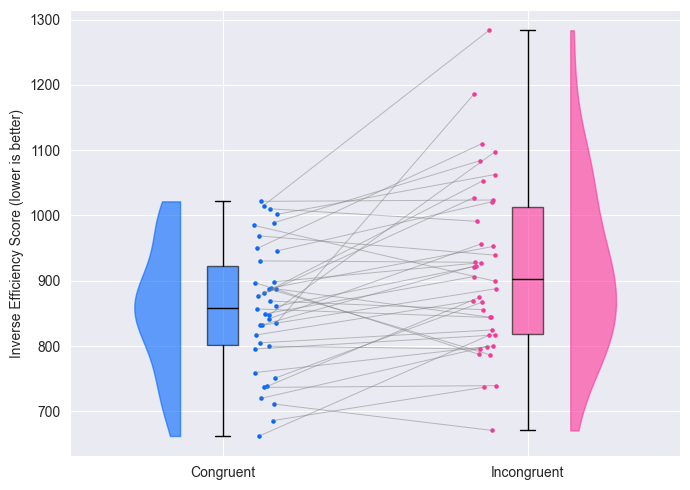

In [6]:
# Single-pass aggregation & reshape
IES_pivoted = (
    IES_dataframe_congruency
    .pivot_table(
        index=['subject_id', 'session'],
        columns='congruency',
        values='IES',
        aggfunc='mean'
    )
    .reset_index()
)
IES_pivoted = IES_pivoted.rename_axis(None, axis=1)
print(IES_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    IES_pivoted,
    column_1='congruent',
    column_2='incongruent',
    labels=['Congruent', 'Incongruent'],
    output_dir=output_dir,
    ylabel_name='Inverse Efficiency Score (lower is better)',
    plot_name='IES congruency'
)

   subject_id     session       stable     volatile
0     sub-005  session-02   778.130080  1012.867725
1     sub-005  session-03   870.335816   911.417580
2     sub-005  session-04   787.409213   890.889264
3     sub-010  session-02   899.109157   887.153444
4     sub-010  session-03   846.481046   854.514740
5     sub-010  session-04   757.467666   870.727149
6     sub-014  session-02   894.595362   836.563265
7     sub-014  session-03   923.760758   987.780529
8     sub-014  session-04   804.796671   938.693478
9     sub-015  session-02   771.136794   790.087345
10    sub-015  session-03   790.216307   915.207949
11    sub-015  session-04   755.596012   754.565740
12    sub-016  session-02   943.209053  1031.584636
13    sub-016  session-03  1033.776644  1009.227094
14    sub-020  session-02   938.078310  1054.331850
15    sub-020  session-03   869.458015  1104.183755
16    sub-020  session-04   990.912098  1080.024852
17    sub-022  session-02   871.718652   982.455704
18    sub-02

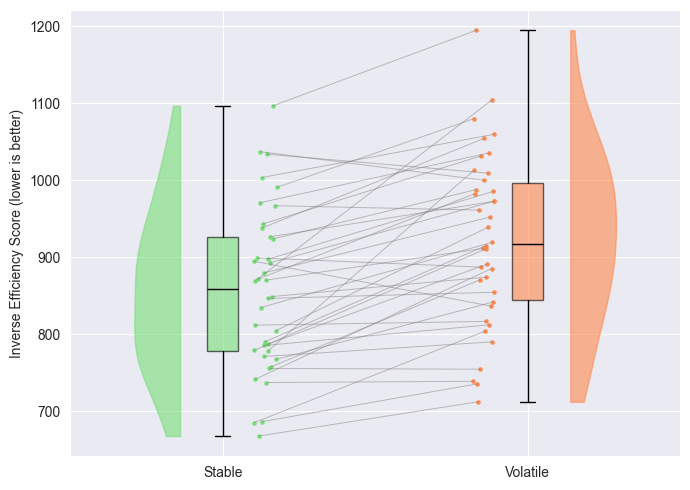

In [7]:
# Single-pass aggregation & reshape
IES_pivoted = (
    IES_dataframe_volatility
    .pivot_table(
        index=['subject_id', 'session'],
        columns='volatility',
        values='IES',
        aggfunc='mean'
    )
    .reset_index()
)
IES_pivoted = IES_pivoted.rename_axis(None, axis=1)
print(IES_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    IES_pivoted,
    column_1='stable',
    column_2='volatile',
    labels=['Stable', 'Volatile'],
    output_dir=output_dir,
    ylabel_name='Inverse Efficiency Score (lower is better)',
    plot_name='IES volatility',
    colours=['#77DF77', '#FF884D']
)

   subject_id     session  congruent_stable  congruent_volatile  \
0     sub-005  session-02        739.710575         1015.004082   
1     sub-005  session-03        900.814581          825.023446   
2     sub-005  session-04        871.318017          902.343487   
3     sub-010  session-02        855.018088          829.300791   
4     sub-010  session-03        846.734880          865.271739   
5     sub-010  session-04        732.846260          876.690265   
6     sub-014  session-02        930.882951          848.880151   
7     sub-014  session-03        889.623730         1046.802149   
8     sub-014  session-04        811.914568          936.698870   
9     sub-015  session-02        776.649467          737.686275   
10    sub-015  session-03        807.795858          828.863390   
11    sub-015  session-04        700.646292          738.362428   
12    sub-016  session-02        897.404497         1015.077505   
13    sub-016  session-03       1018.760897         1025.30951

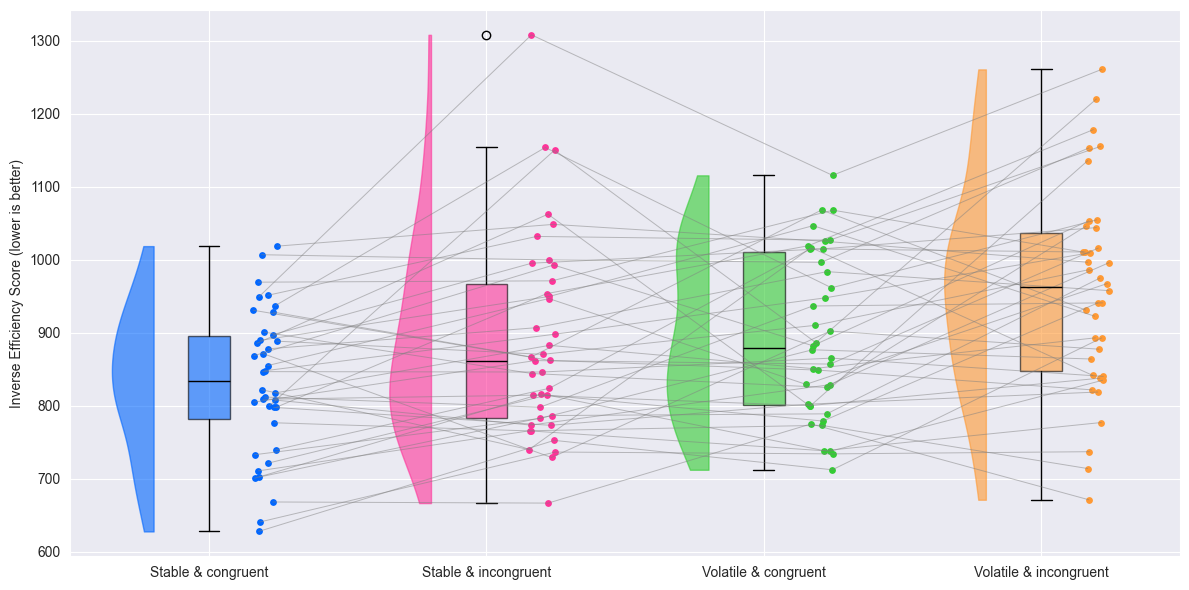

In [8]:
# Single-pass aggregation & reshape
IES_pivoted = (
    IES_dataframe_congruency_volatility
    .pivot_table(
        index=['subject_id', 'session'],
        columns=['congruency', 'volatility'],
        values='IES',
        aggfunc='mean'
    )
    .reset_index()
)
IES_pivoted.columns = [
    f"{a}_{b}" if b else a
    for a, b in IES_pivoted.columns
]
print(IES_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    IES_pivoted,
    columns=['congruent_stable','incongruent_stable','congruent_volatile','incongruent_volatile'],
    labels=['Stable & congruent','Stable & incongruent','Volatile & congruent','Volatile & incongruent'],
    output_dir=output_dir,
    ylabel_name='Inverse Efficiency Score (lower is better)',
    plot_name='IES congruency & volatility'
)

In [9]:
if all(s in unique_sessions for s in all_session_labels):
    # Calculate IES for all sessions
    IES_dataframe_congruency_volatility = utils.analysis_functions.calculate_IES(combined_results_dataframe_all_sessions, ['congruency', 'volatility'])

    # Single-pass aggregation & reshape
    IES_dataframe = (
        IES_dataframe_congruency_volatility
        .pivot_table(
            index=['subject_id', 'session'],
            columns=['congruency', 'volatility'],
            values='IES',
            aggfunc='mean'
        )
        .reset_index()
    )
    IES_dataframe.columns = [
        f"{a}_{b}" if b else a
        for a, b in IES_dataframe.columns
    ]
    print(IES_dataframe)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_scatter_violin_box_2x2(
        IES_dataframe,
        columns=['congruent_stable','incongruent_stable','congruent_volatile','incongruent_volatile'],
        subject_col='subject_id',
        session_col='session',
        labels=['Stable & congruent','Stable & incongruent','Volatile & congruent','Volatile & incongruent'],
        output_dir=output_dir,
        ylabel_name='Inverse Efficiency Score (lower is better)',
        plot_name='IES sessions, congruency & volatility'
    )

# LISAS
Linear Integrated Speed-Accuracy Score = mean RT in condition j (ms) + overall RT SD / overall proportion of errors SD * proportion of errors in condition j (0.10 for example)

In [10]:
LISAS_dataframe_sessions = utils.analysis_functions.calculate_LISAS(combined_results_dataframe)
LISAS_dataframe_congruency = utils.analysis_functions.calculate_LISAS(combined_results_dataframe, ['congruency'])
LISAS_dataframe_volatility = utils.analysis_functions.calculate_LISAS(combined_results_dataframe, ['volatility'])
LISAS_dataframe_congruency_volatility = utils.analysis_functions.calculate_LISAS(combined_results_dataframe, ['congruency', 'volatility'])

In [11]:
if all(s in unique_sessions for s in all_session_labels):
    # Calculate LISAS for all sessions
    LISAS_dataframe_sessions = utils.analysis_functions.calculate_LISAS(combined_results_dataframe_all_sessions)

    # Single-pass aggregation & reshape
    LISAS_pivoted = (
        LISAS_dataframe_sessions
        .pivot_table(
            index=['subject_id'],
            columns=['session'],
            values='LISAS',
            aggfunc='mean'
        )
        .reset_index()
    )
    print(LISAS_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_4_groups(
        LISAS_pivoted,
        columns=['session-01', 'session-02', 'session-03', 'session-04'],
        output_dir=output_dir,
        ylabel_name='LISAS (lower is better)',
        plot_name='LISAS session'
    )

   subject_id     session   congruent  incongruent
0     sub-005  session-02  753.003545   745.008943
1     sub-005  session-03  749.385672   746.927291
2     sub-005  session-04  686.994977   689.639491
3     sub-010  session-02  738.800150   740.014294
4     sub-010  session-03  741.436355   741.059294
5     sub-010  session-04  710.703454   706.878805
6     sub-014  session-02  669.498469   653.736600
7     sub-014  session-03  744.900867   762.665118
8     sub-014  session-04  752.790831   754.031504
9     sub-015  session-02  640.167983   639.038082
10    sub-015  session-03  688.432881   683.541328
11    sub-015  session-04  646.315984   639.990065
12    sub-016  session-02  817.631141   818.371431
13    sub-016  session-03  843.645528   841.325681
14    sub-020  session-02  800.084335   784.624228
15    sub-020  session-03  766.632214   760.829669
16    sub-020  session-04  782.292672   791.945269
17    sub-022  session-02  763.862524   763.556599
18    sub-022  session-03  794.

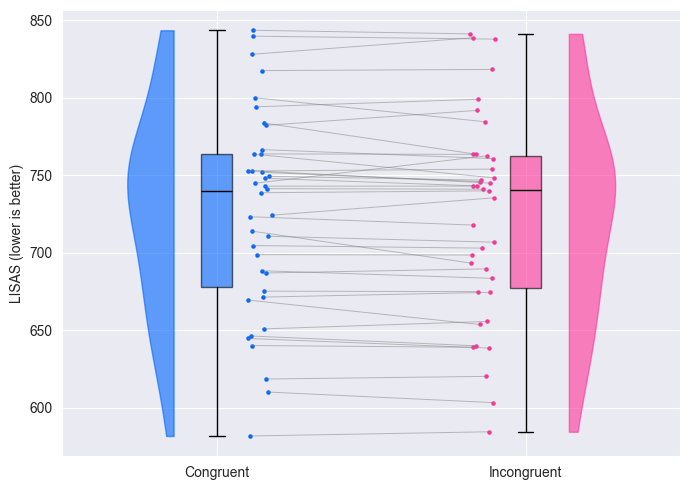

In [12]:
# Single-pass aggregation & reshape
LISAS_pivoted = (
    LISAS_dataframe_congruency
    .pivot_table(
        index=['subject_id', 'session'],
        columns='congruency',
        values='LISAS',
        aggfunc='mean'
    )
    .reset_index()
)
LISAS_pivoted = LISAS_pivoted.rename_axis(None, axis=1)
print(LISAS_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    LISAS_pivoted,
    column_1='congruent',
    column_2='incongruent',
    labels=['Congruent', 'Incongruent'],
    output_dir=output_dir,
        ylabel_name='LISAS (lower is better)',
        plot_name='LISAS congruency'
)

   subject_id     session      stable    volatile
0     sub-005  session-02  758.353932  745.456379
1     sub-005  session-03  749.192825  747.063362
2     sub-005  session-04  689.193151  687.220896
3     sub-010  session-02  738.054219  742.298632
4     sub-010  session-03  740.187090  742.109228
5     sub-010  session-04  719.887550  700.573154
6     sub-014  session-02  662.780692  661.276365
7     sub-014  session-03  765.819192  743.783346
8     sub-014  session-04  757.413927  751.024160
9     sub-015  session-02  634.244793  644.132660
10    sub-015  session-03  689.868931  682.817402
11    sub-015  session-04  647.316140  637.415630
12    sub-016  session-02  819.276025  817.264595
13    sub-016  session-03  840.298773  844.233514
14    sub-020  session-02  793.522115  783.244385
15    sub-020  session-03  771.190068  758.202873
16    sub-020  session-04  793.662714  781.244262
17    sub-022  session-02  766.242911  762.091209
18    sub-022  session-03  805.013860  787.952921


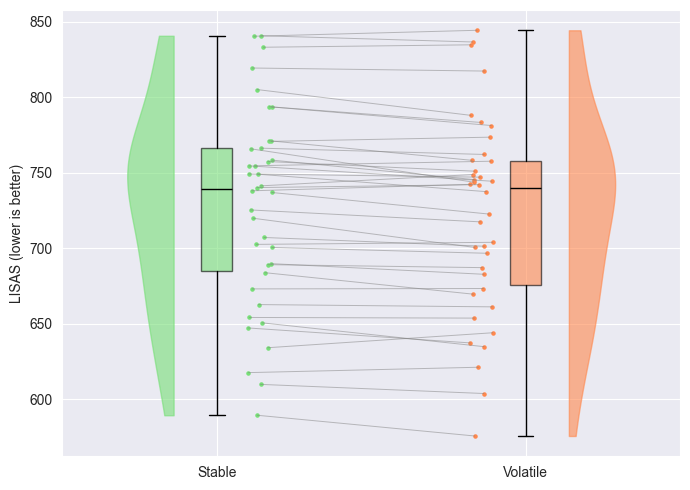

In [13]:
# Single-pass aggregation & reshape
LISAS_pivoted = (
    LISAS_dataframe_volatility
    .pivot_table(
        index=['subject_id', 'session'],
        columns='volatility',
        values='LISAS',
        aggfunc='mean'
    )
    .reset_index()
)
LISAS_pivoted = LISAS_pivoted.rename_axis(None, axis=1)
print(LISAS_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    LISAS_pivoted,
    column_1='stable',
    column_2='volatile',
    labels=['Stable', 'Volatile'],
    output_dir=output_dir,
        ylabel_name='LISAS (lower is better)',
        plot_name='LISAS volatility',
        colours=['#77DF77', '#FF884D']
)

   subject_id     session  congruent_stable  congruent_volatile  \
0     sub-005  session-02        766.899145          748.834557   
1     sub-005  session-03        744.001383          755.625267   
2     sub-005  session-04        683.350268          689.913602   
3     sub-010  session-02        735.833037          741.675923   
4     sub-010  session-03        740.246152          742.290176   
5     sub-010  session-04        726.388210          702.531477   
6     sub-014  session-02        674.587295          664.205774   
7     sub-014  session-03        753.539739          739.163044   
8     sub-014  session-04        755.031208          751.654508   
9     sub-015  session-02        635.282487          645.455212   
10    sub-015  session-03        688.799800          687.941546   
11    sub-015  session-04        652.009128          641.548707   
12    sub-016  session-02        819.910590          816.812910   
13    sub-016  session-03        840.616835          847.58683

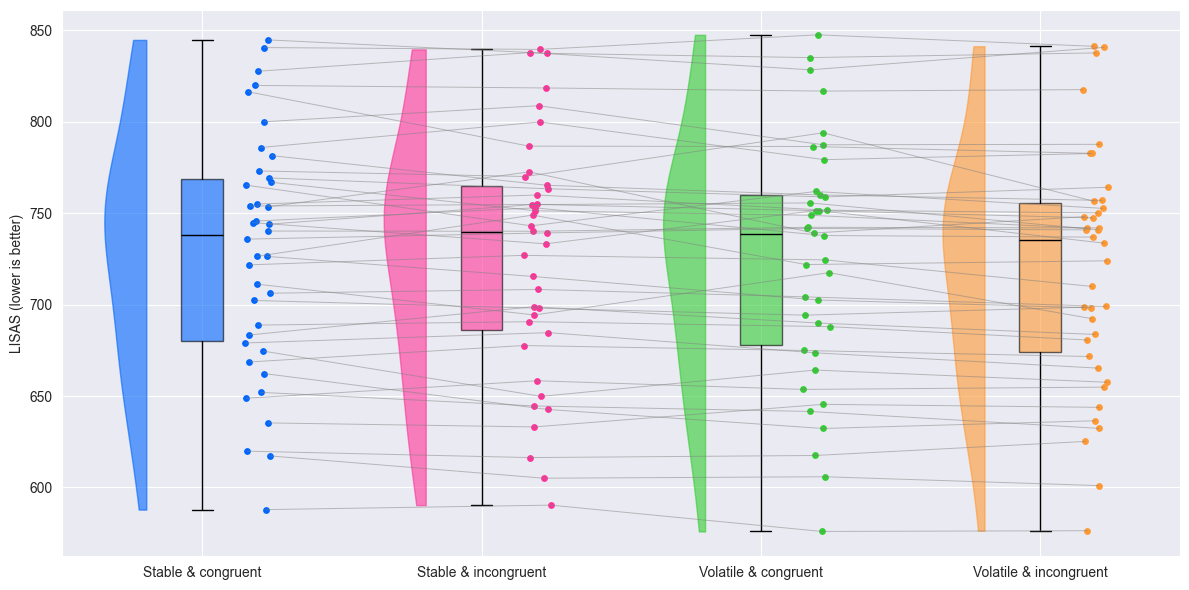

In [14]:
# Single-pass aggregation & reshape
LISAS_pivoted = (
    LISAS_dataframe_congruency_volatility
    .pivot_table(
        index=['subject_id', 'session'],
        columns=['congruency', 'volatility'],
        values='LISAS',
        aggfunc='mean'
    )
    .reset_index()
)
LISAS_pivoted.columns = [
    f"{a}_{b}" if b else a
    for a, b in LISAS_pivoted.columns
]
print(LISAS_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    LISAS_pivoted,
    columns=['congruent_stable','incongruent_stable','congruent_volatile','incongruent_volatile'],
    labels=['Stable & congruent','Stable & incongruent','Volatile & congruent','Volatile & incongruent'],
    output_dir=output_dir,
        ylabel_name='LISAS (lower is better)',
        plot_name='LISAS congruency & volatility'
)

In [15]:
if all(s in unique_sessions for s in all_session_labels):
    # Calculate IES for all sessions
    LISAS_dataframe_congruency_volatility = utils.analysis_functions.calculate_LISAS(combined_results_dataframe_all_sessions, ['congruency', 'volatility'])

    # Single-pass aggregation & reshape
    LISAS_dataframe = (
        LISAS_dataframe_congruency_volatility
        .pivot_table(
            index=['subject_id', 'session'],
            columns=['congruency', 'volatility'],
            values='LISAS',
            aggfunc='mean'
        )
        .reset_index()
    )
    LISAS_dataframe.columns = [
        f"{a}_{b}" if b else a
        for a, b in LISAS_dataframe.columns
    ]
    print(LISAS_dataframe)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_scatter_violin_box_2x2(
        LISAS_dataframe,
        columns=['congruent_stable','incongruent_stable','congruent_volatile','incongruent_volatile'],
        subject_col='subject_id',
        session_col='session',
        labels=['Stable & congruent','Stable & incongruent','Volatile & congruent','Volatile & incongruent'],
        output_dir=output_dir,
        ylabel_name='LISAS (lower is better)',
        plot_name='LISAS sessions, congruency & volatility'
    )

# Plot the relation between speed and accuracy
Quantile probability function

In [16]:
quadratic_trend = False

In [17]:
# suppose your original DataFrame is called df
summary = (
    combined_results_dataframe
    .groupby(['subject_id', 'session', 'congruency'])
    .agg(
        mean_reaction_time=('RT_ms', 'mean'),
        mean_performance=('objectively_correct_boolean', 'mean')
    )
    .reset_index()
)

print(summary)

   subject_id     session   congruency  mean_reaction_time  mean_performance
0     sub-005  session-02    congruent          663.035821          0.773134
1     sub-005  session-02  incongruent          675.769470          0.741433
2     sub-005  session-03    congruent          677.770833          0.782738
3     sub-005  session-03  incongruent          687.018809          0.739812
4     sub-005  session-04    congruent          617.006098          0.692073
5     sub-005  session-04  incongruent          622.195783          0.792169
6     sub-010  session-02    congruent          654.155620          0.757925
7     sub-010  session-02  incongruent          688.321429          0.720779
8     sub-010  session-03    congruent          675.643068          0.769912
9     sub-010  session-03  incongruent          672.078370          0.796238
10    sub-010  session-04    congruent          649.839394          0.803030
11    sub-010  session-04  incongruent          646.595679          0.790123

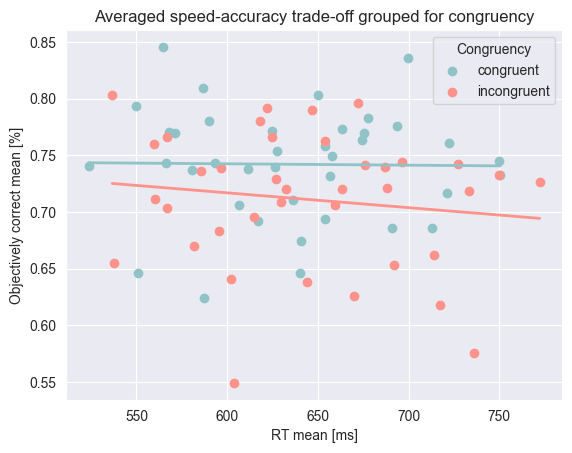

In [18]:
x_col = 'mean_reaction_time'
y_col = 'mean_performance'
group_col = 'congruency'

# Define colours for each group
colour_map = {
    'congruent':   '#90C3C8',
    'incongruent': '#FF928B',
}

fig, ax = plt.subplots()

for cong, group in summary.groupby(group_col):
    x = group[x_col].values
    y = group[y_col].values
    col = colour_map.get(cong, 'gray')

    # Only the scatter gets a legend label
    ax.scatter(x, y, color=col, label=cong)

    # Fit a trendline
    if quadratic_trend:
        a, b, c = np.polyfit(x, y, deg=2)
        x_smooth = np.linspace(x.min(), x.max(), 200)
        y_smooth = a*x_smooth**2 + b*x_smooth + c

        ax.plot(x_smooth, y_smooth, color=col, linewidth=2, label='_nolegend_')
    else:
        m, c = np.polyfit(x, y, deg=1)
        x_line = np.array([x.min(), x.max()])
        y_line = m*x_line + c

        ax.plot(x_line, y_line, color=col, linewidth=2, label='_nolegend_')

ax.set_xlabel('RT mean [ms]')
ax.set_ylabel('Objectively correct mean [%]')
plot_name = 'Averaged speed-accuracy trade-off grouped for congruency'
ax.set_title(plot_name)
ax.legend(title='Congruency')
os.makedirs(output_dir, exist_ok=True)
fig.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

In [19]:
# suppose your original DataFrame is called df
summary = (
    combined_results_dataframe
    .groupby(['subject_id', 'session', 'volatility'])
    .agg(
        mean_reaction_time=('RT_ms', 'mean'),
        mean_performance=('objectively_correct_boolean', 'mean')
    )
    .reset_index()
)

print(summary)

   subject_id     session volatility  mean_reaction_time  mean_performance
0     sub-005  session-02     stable          662.008850          0.843658
1     sub-005  session-02   volatile          677.028391          0.665615
2     sub-005  session-03     stable          679.547826          0.779710
3     sub-005  session-03   volatile          685.309677          0.741935
4     sub-005  session-04     stable          619.776163          0.787791
5     sub-005  session-04   volatile          619.443038          0.693038
6     sub-010  session-02     stable          671.359649          0.733918
7     sub-010  session-02   volatile          668.977636          0.747604
8     sub-010  session-03     stable          680.584071          0.793510
9     sub-010  session-03   volatile          666.827586          0.771160
10    sub-010  session-04     stable          653.877841          0.855114
11    sub-010  session-04   volatile          641.652318          0.728477
12    sub-014  session-02

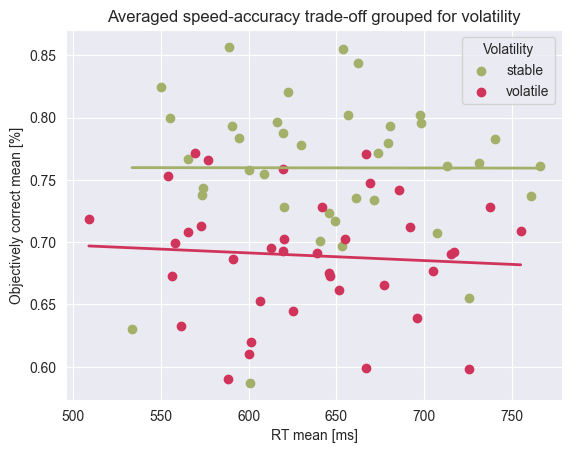

In [20]:
x_col = 'mean_reaction_time'
y_col = 'mean_performance'
group_col = 'volatility'

# Define colours for each group
colour_map = {
    'stable':   '#A4AF69',
    'volatile': '#D1345B',
}

fig, ax = plt.subplots()

for cong, group in summary.groupby(group_col):
    x = group[x_col].values
    y = group[y_col].values
    col = colour_map.get(cong, 'gray')

    # Only the scatter gets a legend label
    ax.scatter(x, y, color=col, label=cong)

    # Fit a trendline
    if quadratic_trend:
        a, b, c = np.polyfit(x, y, deg=2)
        x_smooth = np.linspace(x.min(), x.max(), 200)
        y_smooth = a*x_smooth**2 + b*x_smooth + c

        ax.plot(x_smooth, y_smooth, color=col, linewidth=2, label='_nolegend_')
    else:
        m, c = np.polyfit(x, y, deg=1)
        x_line = np.array([x.min(), x.max()])
        y_line = m*x_line + c

        ax.plot(x_line, y_line, color=col, linewidth=2, label='_nolegend_')

ax.set_xlabel('RT mean [ms]')
ax.set_ylabel('Objectively correct mean [%]')
plot_name = 'Averaged speed-accuracy trade-off grouped for volatility'
ax.set_title(plot_name)
ax.legend(title='Volatility')
os.makedirs(output_dir, exist_ok=True)
fig.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

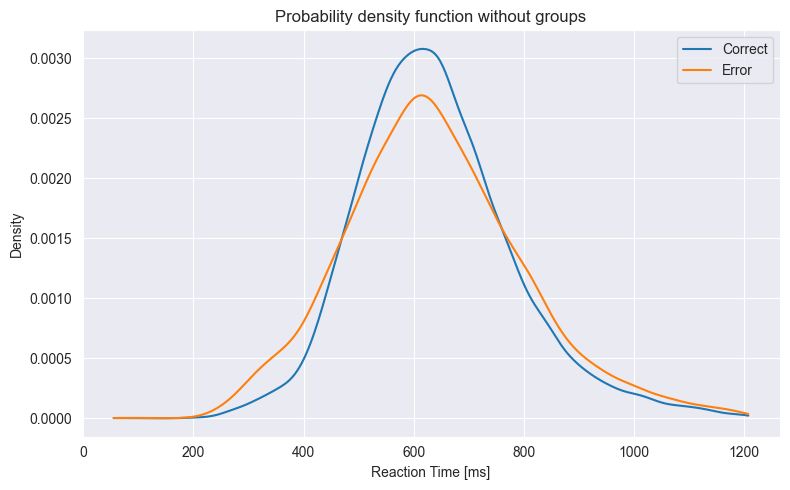

In [21]:
# assume `df` is your DataFrame
# split RTs by correctness
rts_correct = combined_results_dataframe.loc[combined_results_dataframe['objectively_correct_boolean'] == 1, 'RT_ms']
rts_error   = combined_results_dataframe.loc[combined_results_dataframe['objectively_correct_boolean'] == 0, 'RT_ms']

# compute KDEs
kde_correct = gaussian_kde(rts_correct)
kde_error   = gaussian_kde(rts_error)

# choose a common x‐axis range
xmin, xmax = combined_results_dataframe['RT_ms'].min(), combined_results_dataframe['RT_ms'].max()
x_vals = np.linspace(xmin, xmax, 500)

# plot both densities
plt.figure(figsize=(8, 5))
plt.plot(x_vals, kde_correct(x_vals), label='Correct')
plt.plot(x_vals, kde_error(  x_vals), label='Error')
plt.xlabel('Reaction Time [ms]')
plt.ylabel('Density')
plot_name = 'Probability density function without groups'
plt.title(plot_name)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

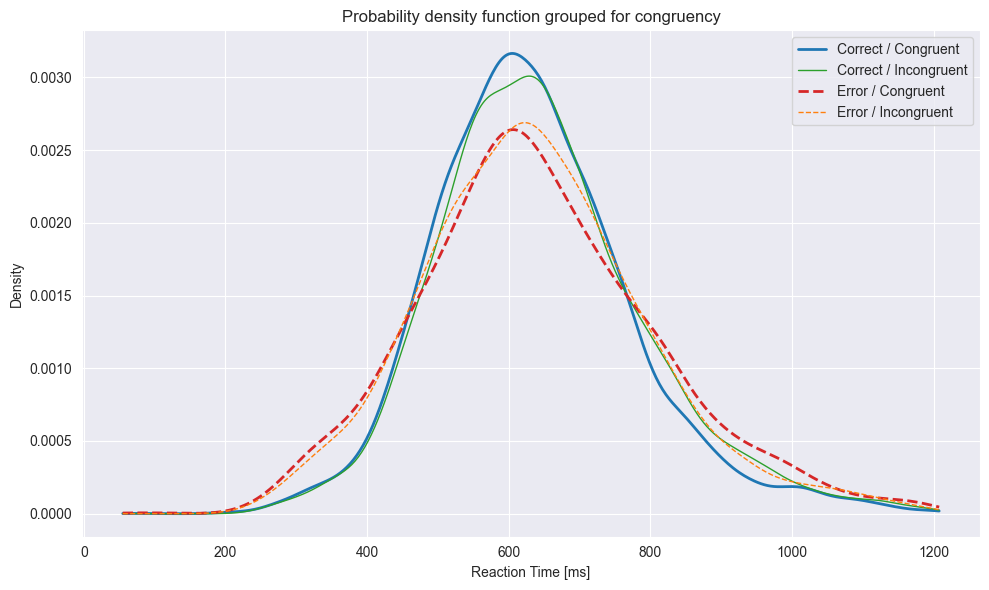

In [22]:
# define your two factors
correctness_levels = {
    1: 'Correct',
    0: 'Error'
}
congruency_levels = ['congruent', 'incongruent']

# Define your color map for (correctness, congruency)
color_map = {
    (1, 'congruent'):   'tab:blue',
    (1, 'incongruent'): 'tab:green',
    (0, 'congruent'):   'tab:red',
    (0, 'incongruent'): 'tab:orange'
}

# Prepare x-axis
xmin, xmax = combined_results_dataframe['RT_ms'].min(), combined_results_dataframe['RT_ms'].max()
x_vals = np.linspace(xmin, xmax, 500)

plt.figure(figsize=(10, 6))

# Loop through each combination
for obj_val, obj_label in [(1, 'Correct'), (0, 'Error')]:
    for cong in ['congruent', 'incongruent']:
        subset = combined_results_dataframe[
            (combined_results_dataframe['objectively_correct_boolean'] == obj_val) &
            (combined_results_dataframe['congruency'] == cong)
        ]['RT_ms']
        if len(subset) < 2:
            continue

        kde = gaussian_kde(subset)
        label = f"{obj_label} / {cong.capitalize()}"
        c = color_map[(obj_val, cong)]

        plt.plot(x_vals, kde(x_vals),
                 label=label,
                 color=c,
                 linestyle='-' if obj_val == 1 else '--',
                 linewidth=2 if cong == 'congruent' else 1)

# finalize
plt.xlabel('Reaction Time [ms]')
plt.ylabel('Density')
plot_name = 'Probability density function grouped for congruency'
plt.title(plot_name)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

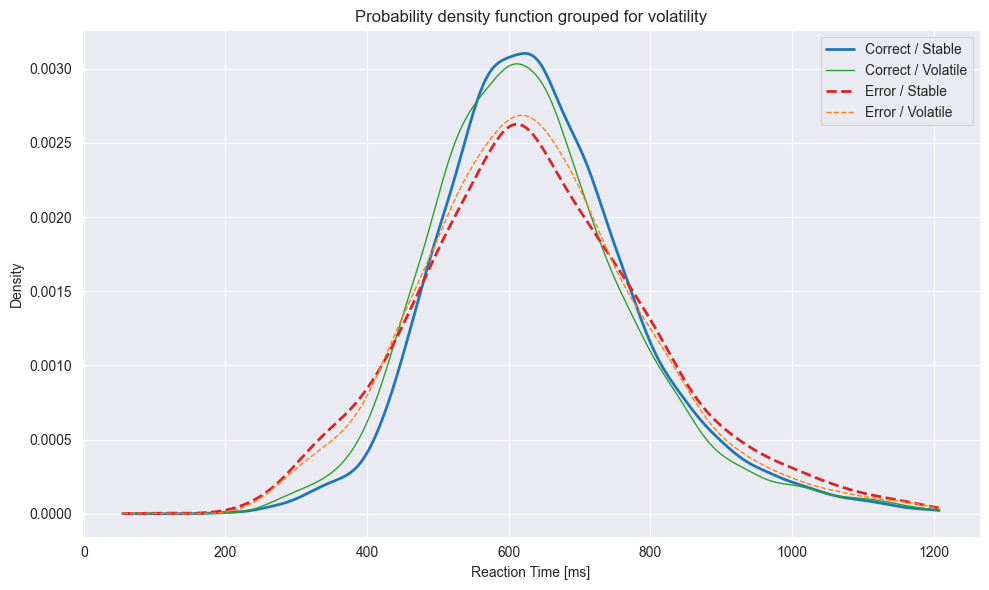

In [23]:
# define your two factors
correctness_levels = {
    1: 'Correct',
    0: 'Error'
}
congruency_levels = ['stable', 'volatile']

# Define your color map for (correctness, congruency)
color_map = {
    (1, 'stable'):   'tab:blue',
    (1, 'volatile'): 'tab:green',
    (0, 'stable'):   'tab:red',
    (0, 'volatile'): 'tab:orange'
}

# Prepare x-axis
xmin, xmax = combined_results_dataframe['RT_ms'].min(), combined_results_dataframe['RT_ms'].max()
x_vals = np.linspace(xmin, xmax, 500)

plt.figure(figsize=(10, 6))

# Loop through each combination
for obj_val, obj_label in [(1, 'Correct'), (0, 'Error')]:
    for volatility in ['stable', 'volatile']:
        subset = combined_results_dataframe[
            (combined_results_dataframe['objectively_correct_boolean'] == obj_val) &
            (combined_results_dataframe['volatility'] == volatility)
        ]['RT_ms']
        if len(subset) < 2:
            continue

        kde = gaussian_kde(subset)
        label = f"{obj_label} / {volatility.capitalize()}"
        c = color_map[(obj_val, volatility)]

        plt.plot(x_vals, kde(x_vals),
                 label=label,
                 color=c,
                 linestyle='-' if obj_val == 1 else '--',
                 linewidth=2 if volatility == 'stable' else 1)

# finalize
plt.xlabel('Reaction Time [ms]')
plt.ylabel('Density')
plot_name = 'Probability density function grouped for volatility'
plt.title(plot_name)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

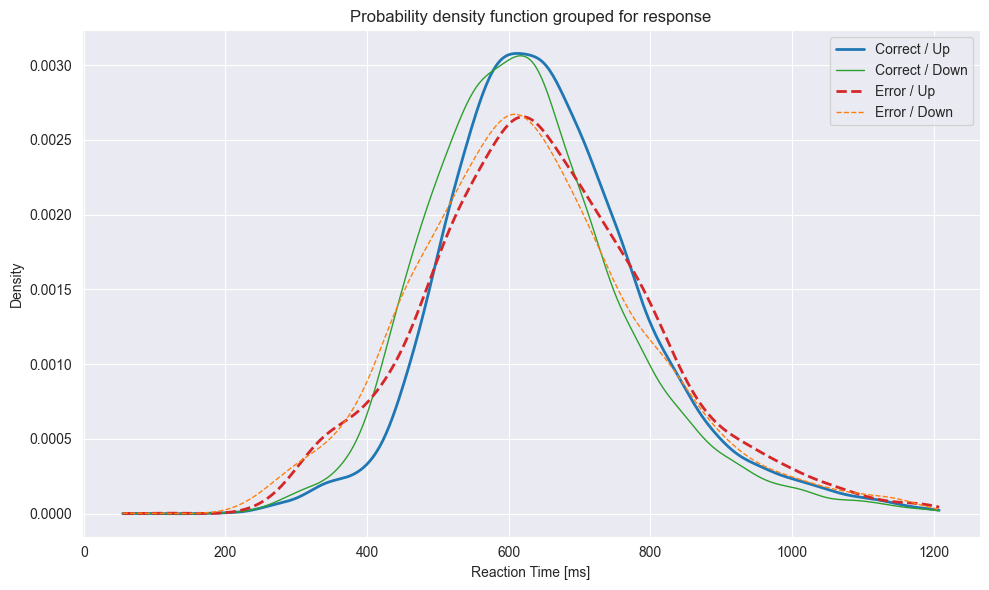

In [24]:
# define your two factors
correctness_levels = {
    1: 'Correct',
    0: 'Error'
}
congruency_levels = ['up', 'down']

# Define your color map for (correctness, congruency)
color_map = {
    (1, 'up'):   'tab:blue',
    (1, 'down'): 'tab:green',
    (0, 'up'):   'tab:red',
    (0, 'down'): 'tab:orange'
}

# Prepare x-axis
xmin, xmax = combined_results_dataframe['RT_ms'].min(), combined_results_dataframe['RT_ms'].max()
x_vals = np.linspace(xmin, xmax, 500)

plt.figure(figsize=(10, 6))

# Loop through each combination
for obj_val, obj_label in [(1, 'Correct'), (0, 'Error')]:
    for response_direction in ['up', 'down']:
        subset = combined_results_dataframe[
            (combined_results_dataframe['objectively_correct_boolean'] == obj_val) &
            (combined_results_dataframe['response'] == response_direction)
        ]['RT_ms']
        if len(subset) < 2:
            continue

        kde = gaussian_kde(subset)
        label = f"{obj_label} / {response_direction.capitalize()}"
        c = color_map[(obj_val, response_direction)]

        plt.plot(x_vals, kde(x_vals),
                 label=label,
                 color=c,
                 linestyle='-' if obj_val == 1 else '--',
                 linewidth=2 if response_direction == 'up' else 1)

# finalize
plt.xlabel('Reaction Time [ms]')
plt.ylabel('Density')
plot_name = 'Probability density function grouped for response'
plt.title(plot_name)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()